# FraudGuard-AI: Machine Learning Experiments

This notebook documents the machine learning workflow for FraudGuard-AI, an online payment fraud detection system. It is organized for academic review and can be executed from the first cell to the last cell without manual path changes. The workflow uses the repository dataset at `ml/dataset/fraud.csv`, trains several supervised classifiers, evaluates neural-network variants, applies feature selection, exports app-compatible result files, and performs KMeans clustering with PCA visualization.


## Setup and Reproducibility

This section imports the libraries used throughout the experiment, resolves repository paths from the notebook location, creates artifact folders, and fixes random seeds. Reproducible seeds are used in sampling, train/test splitting, model training, hyperparameter search, and clustering.


In [1]:
from pathlib import Path
import hashlib
import json
import random
import sys
import warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn import __version__ as sklearn_version
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
SAMPLE_SIZE = 50_000
TEST_SIZE = 0.20
SELECT_K = 5
CLUSTER_SAMPLE_SIZE = 8_000
PCA_PLOT_SAMPLE_SIZE = 5_000

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "ml" / "paths.py").exists():
            return candidate
    raise RuntimeError("Could not locate repository root containing ml/paths.py")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml.paths import (
    BEST_MODEL_PATH,
    BEST_MODEL_REGISTRY_PATH,
    CLUSTERING_RESULTS_CSV_PATH,
    CLUSTERING_RESULTS_JSON_PATH,
    COLUMNS_PATH,
    COMPATIBILITY_MODEL_PATH,
    DATASET_PATH,
    FEATURE_IMPORTANCE_CSV_PATH,
    FEATURE_IMPORTANCE_JSON_PATH,
    KMEANS_PCA_CLUSTERS_PATH,
    KMEANS_PCA_TRUE_LABELS_PATH,
    MODEL_COMPARISON_CSV_PATH,
    MODEL_COMPARISON_JSON_PATH,
    MODEL_DIR,
    NOTEBOOK_EXPERIMENT_METADATA_PATH,
    NOTEBOOK_EXPERIMENT_MODEL_DIR,
    NOTEBOOK_FEATURE_COLUMNS_PATH,
    NOTEBOOK_STANDARD_SCALER_PATH,
    RESULTS_DIR,
    SCALER_PATH,
    TRAINING_METADATA_PATH,
    repo_relative,
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_EXPERIMENT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]
NUMERIC_FEATURES = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]
TARGET = "isFraud"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Models directory: {MODEL_DIR}")


Project root: C:\Users\olsas\Downloads\fraudguard-ai
Dataset path: C:\Users\olsas\Downloads\fraudguard-ai\ml\dataset\fraud.csv
Results directory: C:\Users\olsas\Downloads\fraudguard-ai\ml\results
Models directory: C:\Users\olsas\Downloads\fraudguard-ai\ml\models


## Dataset Loading

The project dataset is loaded from `ml/dataset/fraud.csv`. The notebook verifies that the fraud label and the main transaction fields required by the project are present before continuing. Records with missing values in the modeling columns are removed to avoid inconsistent training inputs.


In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)
required_columns = FEATURES + [TARGET]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

df = df.dropna(subset=required_columns).copy()
df[TARGET] = df[TARGET].astype(int)

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

dataset_metadata = {
    "path": repo_relative(DATASET_PATH),
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "sha256": sha256_file(DATASET_PATH),
    "target": TARGET,
}

display(pd.DataFrame([dataset_metadata]))
display(df[required_columns].head())


,path,rows,columns,sha256,target
0,ml/dataset/fraud.csv,6362620,11,63ac23148402d47d01e7c9d79ac4d0ff027ef1bc1e0346...,isFraud


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


## Data Exploration

Exploratory analysis checks the target distribution, transaction-type distribution, missing values, numeric summaries, and linear relationships between numeric attributes and the fraud label. These checks motivate the later use of stratified sampling, class-weighted classifiers, and scaled numeric features.


,isFraud,count,percentage
0,0,6354407,99.870918
1,1,8213,0.129082


,transaction_type,count
0,CASH_OUT,2237500
1,PAYMENT,2151495
2,CASH_IN,1399284
3,TRANSFER,532909
4,DEBIT,41432


,column,missing_values
0,type,0
1,amount,0
2,oldbalanceOrg,0
3,newbalanceOrig,0
4,oldbalanceDest,0
5,newbalanceDest,0
6,isFraud,0


,count,mean,std,min,25%,50%,75%,max
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00


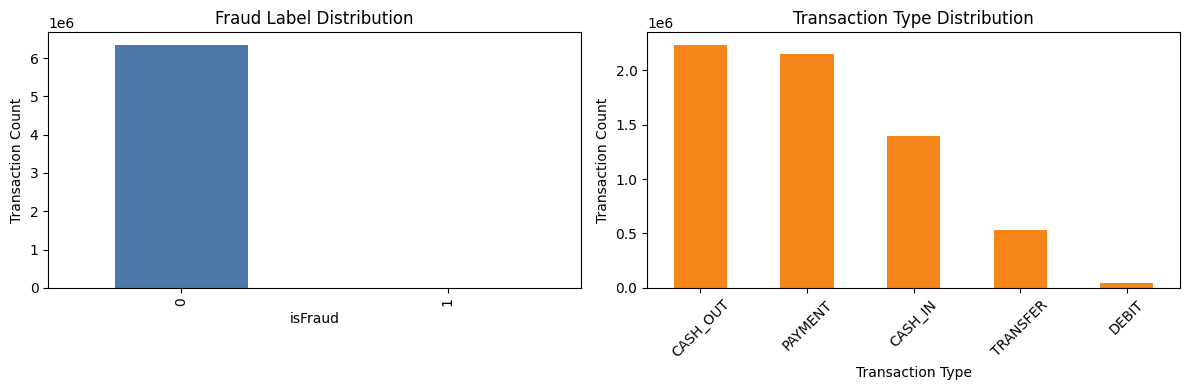

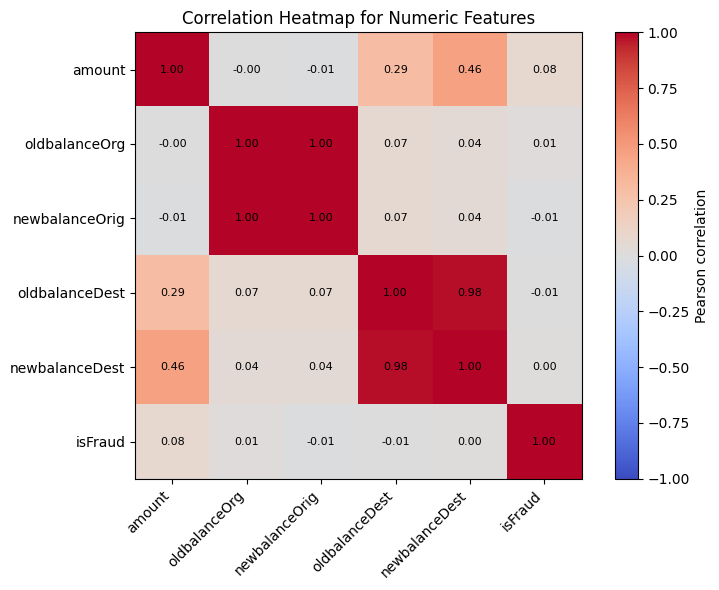

In [3]:
target_distribution = (
    df[TARGET]
    .value_counts()
    .rename_axis("isFraud")
    .reset_index(name="count")
    .assign(percentage=lambda table: table["count"] / len(df) * 100)
)
type_distribution = (
    df["type"]
    .value_counts()
    .rename_axis("transaction_type")
    .reset_index(name="count")
)
missing_summary = df[required_columns].isna().sum().reset_index()
missing_summary.columns = ["column", "missing_values"]

display(target_distribution)
display(type_distribution)
display(missing_summary)
display(df[NUMERIC_FEATURES + [TARGET]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_distribution.plot(kind="bar", x="isFraud", y="count", ax=axes[0], legend=False, color="#4c78a8")
axes[0].set_title("Fraud Label Distribution")
axes[0].set_xlabel("isFraud")
axes[0].set_ylabel("Transaction Count")

type_distribution.plot(kind="bar", x="transaction_type", y="count", ax=axes[1], legend=False, color="#f58518")
axes[1].set_title("Transaction Type Distribution")
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Transaction Count")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

correlation = df[NUMERIC_FEATURES + [TARGET]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap for Numeric Features")
ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))
ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation.index)
for i in range(len(correlation.index)):
    for j in range(len(correlation.columns)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()


## Preprocessing

The transaction type is encoded with one-hot encoding and numeric transaction fields are retained. Because the full dataset is highly imbalanced and large for repeated academic experiments, the notebook uses a stratified sample for model comparison while preserving the fraud/non-fraud ratio. Scaling is handled inside model pipelines for algorithms that depend on feature distance or gradient optimization.


In [4]:
if len(df) > SAMPLE_SIZE:
    sampled_df, _ = train_test_split(
        df[required_columns],
        train_size=SAMPLE_SIZE,
        stratify=df[TARGET],
        random_state=RANDOM_STATE,
    )
else:
    sampled_df = df[required_columns].copy()

sampled_df = sampled_df.reset_index(drop=True)
X_raw = sampled_df[FEATURES].copy()
y = sampled_df[TARGET].astype(int).copy()
X = pd.get_dummies(X_raw, columns=["type"], drop_first=False)
feature_columns = X.columns.tolist()

print(f"Modeling sample shape: {sampled_df.shape}")
print(f"Encoded feature count: {len(feature_columns)}")
display(y.value_counts().rename_axis("isFraud").reset_index(name="count"))
display(pd.DataFrame({"feature": feature_columns}))


Modeling sample shape: (50000, 7)
Encoded feature count: 10


,isFraud,count
0,0,49935
1,1,65


,feature
0,amount
1,oldbalanceOrg
2,newbalanceOrig
3,oldbalanceDest
4,newbalanceDest
5,type_CASH_IN
6,type_CASH_OUT
7,type_DEBIT
8,type_PAYMENT
9,type_TRANSFER


## Train/Test Split

A stratified train/test split is used so the rare fraud class is represented in both partitions. The test set is held out from model fitting and hyperparameter tuning, then used for final comparison metrics.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "partition": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "fraud_cases": [int(y_train.sum()), int(y_test.sum())],
        "fraud_rate_percent": [float(y_train.mean() * 100), float(y_test.mean() * 100)],
    }
)
display(split_summary)


,partition,rows,fraud_cases,fraud_rate_percent
0,train,40000,52,0.13
1,test,10000,13,0.13


## Feature Selection

`SelectKBest` with the ANOVA F-test ranks the encoded variables by their statistical relationship with the target. The selected feature subset is evaluated later to show whether a smaller feature set changes classifier performance.


In [6]:
selector = SelectKBest(score_func=f_classif, k=min(SELECT_K, X_train.shape[1]))
selector.fit(X_train, y_train)

feature_selection_df = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "score": selector.scores_,
            "selected": selector.get_support(),
        }
    )
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
selected_features = feature_selection_df.loc[feature_selection_df["selected"], "feature"].tolist()

display(feature_selection_df)
print(f"Selected features: {selected_features}")


,feature,score,selected
0,amount,555.627076,True
1,type_TRANSFER,95.482541,True
2,oldbalanceOrg,27.842795,True
3,type_PAYMENT,27.004317,True
4,type_CASH_IN,14.358086,True
5,type_CASH_OUT,7.985507,False
6,newbalanceDest,1.995574,False
7,oldbalanceDest,1.759773,False
8,newbalanceOrig,0.764358,False
9,type_DEBIT,0.327456,False


Selected features: ['amount', 'type_TRANSFER', 'oldbalanceOrg', 'type_PAYMENT', 'type_CASH_IN']


## Model Training

The supervised classification stage compares Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, and a neural network implemented with scikit-learn `MLPClassifier`. Class imbalance is handled through class weighting for classifiers that support it. Logistic Regression, KNN, and MLP use `StandardScaler` inside a pipeline.


In [7]:
model_configs = {
    "Logistic Regression": {
        "estimator": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=1000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "params": {
            "model__C": [1.0, 10.0],
            "model__solver": ["liblinear"],
        },
        "type": "Linear classifier",
        "description": "Interpretable baseline classifier with balanced class weights.",
    },
    "KNN": {
        "estimator": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier()),
            ]
        ),
        "params": {
            "model__n_neighbors": [3, 5],
            "model__weights": ["distance"],
        },
        "type": "Instance-based classifier",
        "description": "Distance-based classifier for local transaction similarity.",
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        "params": {
            "max_depth": [10, 15],
            "min_samples_split": [2, 5],
            "criterion": ["gini", "entropy"],
        },
        "type": "Tree classifier",
        "description": "Rule-based classifier that captures non-linear thresholds.",
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "params": {
            "n_estimators": [80, 100],
            "max_depth": [10, 20],
            "min_samples_split": [2, 5],
        },
        "type": "Ensemble classifier",
        "description": "Tree ensemble that reduces variance and models non-linear interactions.",
    },
    "Neural Network": {
        "estimator": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    MLPClassifier(
                        max_iter=300,
                        early_stopping=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "params": {
            "model__hidden_layer_sizes": [(32,), (64, 32)],
            "model__activation": ["relu", "tanh"],
            "model__learning_rate_init": [0.001, 0.01],
        },
        "type": "Neural network classifier",
        "description": "Multilayer perceptron for non-linear decision boundaries.",
    },
}

print(f"Prepared {len(model_configs)} model configurations.")


Prepared 5 model configurations.


## Hyperparameter Tuning

Each model is tuned with `GridSearchCV` using three-fold cross-validation and F1-score as the optimization metric. F1-score is appropriate because fraud detection must balance precision and recall under severe class imbalance.


In [8]:
def probability_scores(model, features):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(features)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    return model.predict(features)

def evaluate_model(model, features, labels):
    predictions = model.predict(features)
    probabilities = probability_scores(model, features)
    cm = confusion_matrix(labels, predictions, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "confusion_matrix": {
            "trueNegatives": int(tn),
            "falsePositives": int(fp),
            "falseNegatives": int(fn),
            "truePositives": int(tp),
        },
    }

trained_models = {}
result_rows = []

for model_name, config in model_configs.items():
    print(f"Training {model_name}...")
    search = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        scoring="f1",
        cv=3,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    best_estimator = search.best_estimator_
    metrics = evaluate_model(best_estimator, X_test, y_test)
    trained_models[model_name] = {
        "model": best_estimator,
        "search": search,
        "config": config,
        "metrics": metrics,
    }
    result_rows.append(
        {
            "modelName": model_name,
            "modelType": config["type"],
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1Score": metrics["f1"],
            "rocAuc": metrics["roc_auc"],
            "cvBestF1": float(search.best_score_),
            "bestParams": search.best_params_,
        }
    )

results_df = pd.DataFrame(result_rows).sort_values("f1Score", ascending=False).reset_index(drop=True)
best_model_name = results_df.loc[0, "modelName"]
best_model = trained_models[best_model_name]["model"]
display(results_df)
print(f"Best model by test F1-score: {best_model_name}")


Training Logistic Regression...


Training KNN...


Training Decision Tree...


Training Random Forest...


Training Neural Network...


,modelName,modelType,accuracy,precision,recall,f1Score,rocAuc,cvBestF1,bestParams
0,Random Forest,Ensemble classifier,0.9994,1.000000,0.538462,0.700000,0.995741,0.761973,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
1,Decision Tree,Tree classifier,0.9991,0.700000,0.538462,0.608696,0.769081,0.620589,"{'criterion': 'gini', 'max_depth': 15, 'min_sa..."
2,KNN,Instance-based classifier,0.9992,0.857143,0.461538,0.600000,0.730527,0.591795,"{'model__n_neighbors': 3, 'model__weights': 'd..."
3,Neural Network,Neural network classifier,0.9988,1.000000,0.076923,0.142857,0.899169,0.705128,"{'model__activation': 'tanh', 'model__hidden_l..."
4,Logistic Regression,Linear classifier,0.9496,0.025145,1.000000,0.049057,0.993861,0.051547,"{'model__C': 10.0, 'model__solver': 'liblinear'}"


Best model by test F1-score: Random Forest


## Neural Network Architectures

This section compares multiple MLP architectures and activations outside the main grid-search table. The purpose is to show how hidden-layer size, activation function, and learning rate influence fraud-class performance.


In [9]:
mlp_architectures = [
    {"name": "MLP 32 ReLU", "hidden_layer_sizes": (32,), "activation": "relu", "learning_rate_init": 0.001},
    {"name": "MLP 64 ReLU", "hidden_layer_sizes": (64,), "activation": "relu", "learning_rate_init": 0.001},
    {"name": "MLP 64-32 ReLU", "hidden_layer_sizes": (64, 32), "activation": "relu", "learning_rate_init": 0.001},
    {"name": "MLP 32 Tanh Fast LR", "hidden_layer_sizes": (32,), "activation": "tanh", "learning_rate_init": 0.01},
]

mlp_rows = []
for config in mlp_architectures:
    mlp_pipeline = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                MLPClassifier(
                    hidden_layer_sizes=config["hidden_layer_sizes"],
                    activation=config["activation"],
                    learning_rate_init=config["learning_rate_init"],
                    max_iter=300,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    mlp_pipeline.fit(X_train, y_train)
    metrics = evaluate_model(mlp_pipeline, X_test, y_test)
    mlp_rows.append(
        {
            "architecture": config["name"],
            "hiddenLayerSizes": str(config["hidden_layer_sizes"]),
            "activation": config["activation"],
            "learningRate": config["learning_rate_init"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1Score": metrics["f1"],
            "rocAuc": metrics["roc_auc"],
        }
    )

mlp_architecture_df = pd.DataFrame(mlp_rows).sort_values("f1Score", ascending=False)
display(mlp_architecture_df)


,architecture,hiddenLayerSizes,activation,learningRate,precision,recall,f1Score,rocAuc
3,MLP 32 Tanh Fast LR,"(32,)",tanh,0.010,1.0,0.230769,0.375,0.986798
0,MLP 32 ReLU,"(32,)",relu,0.001,0.0,0.000000,0.000,0.789411
1,MLP 64 ReLU,"(64,)",relu,0.001,0.0,0.000000,0.000,0.853879
2,MLP 64-32 ReLU,"(64, 32)",relu,0.001,0.0,0.000000,0.000,0.948556


## Evaluation and Result Exports

The final evaluation exports app-compatible model comparison files, confusion matrices, feature importance values, model artifacts, and metadata. The same files are consumed by the backend and frontend pages for model comparison and reporting.


,modelName,trueNegatives,falsePositives,falseNegatives,truePositives
0,Logistic Regression,9483,504,0,13
1,KNN,9986,1,7,6
2,Decision Tree,9984,3,6,7
3,Random Forest,9987,0,6,7
4,Neural Network,9987,0,12,1


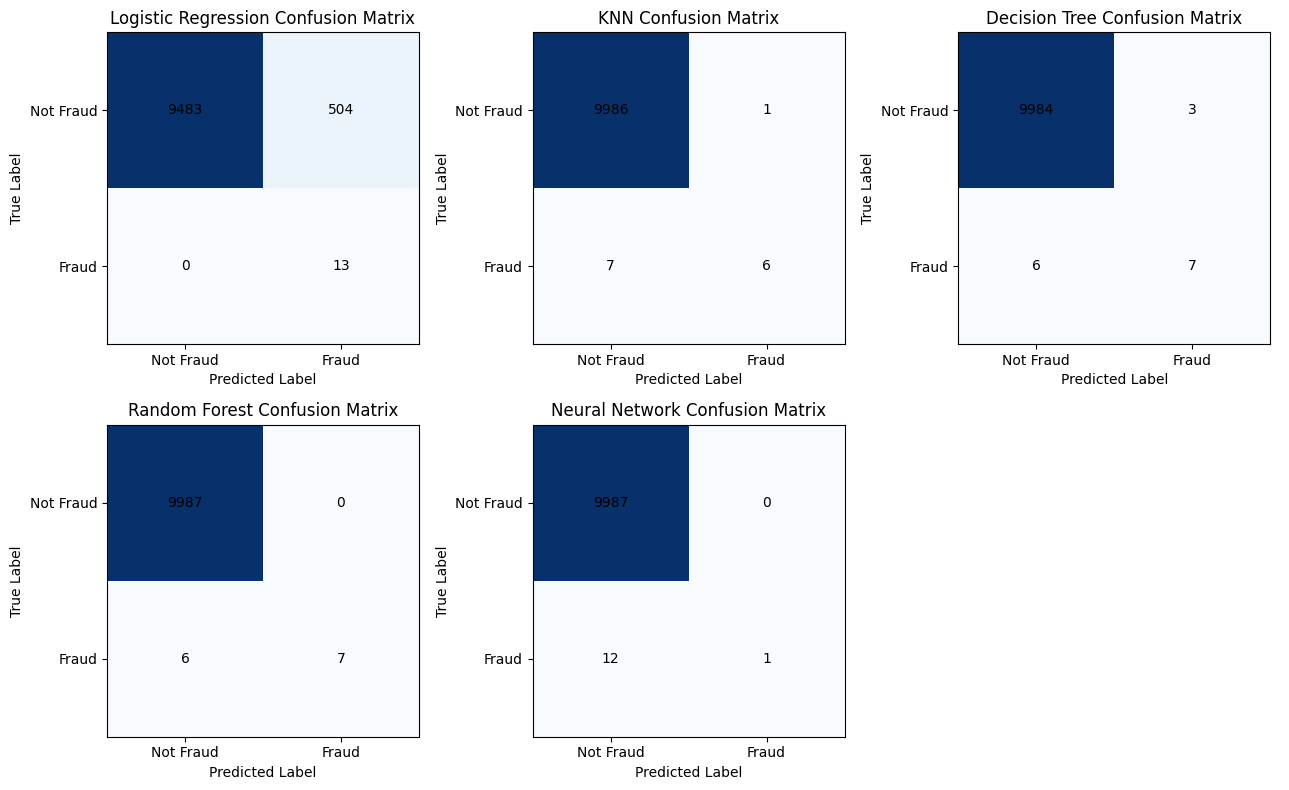

In [10]:
confusion_rows = []
for model_name, item in trained_models.items():
    cm = item["metrics"]["confusion_matrix"]
    confusion_rows.append({"modelName": model_name, **cm})

confusion_df = pd.DataFrame(confusion_rows)
display(confusion_df)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for ax, (model_name, item) in zip(axes, trained_models.items()):
    cm_values = np.array(list(item["metrics"]["confusion_matrix"].values())).reshape(2, 2)
    image = ax.imshow(cm_values, cmap="Blues")
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not Fraud", "Fraud"])
    ax.set_yticklabels(["Not Fraud", "Fraud"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_values[i, j]), ha="center", va="center", color="black")
for ax in axes[len(trained_models):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [11]:
best_reason = (
    f"{best_model_name} achieved the strongest held-out F1-score "
    "while maintaining a practical balance between precision and recall for the rare fraud class."
)

model_payload_items = []
for row in result_rows:
    model_name = row["modelName"]
    item = trained_models[model_name]
    metrics = item["metrics"]
    model_payload_items.append(
        {
            "modelName": model_name,
            "modelType": item["config"]["type"],
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1Score": metrics["f1"],
            "rocAuc": metrics["roc_auc"],
            "confusionMatrix": metrics["confusion_matrix"],
            "status": "Best Model" if model_name == best_model_name else "Tested",
            "shortDescription": item["config"]["description"],
            "isBestModel": model_name == best_model_name,
            "hyperparameters": {
                "tested": item["config"]["params"],
                "selected": item["search"].best_params_,
            },
            "cvBestF1": float(item["search"].best_score_),
        }
    )

model_comparison_payload = {
    "datasetName": "Fraud transaction dataset",
    "datasetPath": repo_relative(DATASET_PATH),
    "problemType": "Binary classification",
    "targetVariable": TARGET,
    "sampleSize": int(len(sampled_df)),
    "testSize": int(len(X_test)),
    "bestModelName": best_model_name,
    "bestModelReason": best_reason,
    "evaluationSource": "ml/notebooks/fraud_detection_ml_experiments.ipynb",
    "generatedAt": datetime.now(timezone.utc).isoformat(),
    "models": model_payload_items,
}

with MODEL_COMPARISON_JSON_PATH.open("w", encoding="utf-8") as file:
    json.dump(model_comparison_payload, file, indent=2, default=str)

model_comparison_csv = pd.DataFrame(
    [
        {
            **{key: value for key, value in item.items() if key not in {"confusionMatrix", "hyperparameters"}},
            **item["confusionMatrix"],
            "selectedHyperparameters": json.dumps(item["hyperparameters"]["selected"], default=str),
        }
        for item in model_payload_items
    ]
)
model_comparison_csv.to_csv(MODEL_COMPARISON_CSV_PATH, index=False)

confusion_payload = {
    "datasetName": "Fraud transaction dataset",
    "targetVariable": TARGET,
    "generatedAt": datetime.now(timezone.utc).isoformat(),
    "matrices": confusion_rows,
}
confusion_json_path = RESULTS_DIR / "confusion_matrices.json"
confusion_csv_path = RESULTS_DIR / "confusion_matrices.csv"
with confusion_json_path.open("w", encoding="utf-8") as file:
    json.dump(confusion_payload, file, indent=2)
confusion_df.to_csv(confusion_csv_path, index=False)

joblib.dump(best_model, BEST_MODEL_PATH)
joblib.dump(best_model, COMPATIBILITY_MODEL_PATH)
joblib.dump(feature_columns, COLUMNS_PATH)
joblib.dump(None, SCALER_PATH)
joblib.dump(feature_columns, NOTEBOOK_FEATURE_COLUMNS_PATH)
joblib.dump(StandardScaler().fit(X_train), NOTEBOOK_STANDARD_SCALER_PATH)

print(f"Saved model comparison JSON: {MODEL_COMPARISON_JSON_PATH}")
print(f"Saved model comparison CSV: {MODEL_COMPARISON_CSV_PATH}")
print(f"Saved confusion matrix exports: {confusion_json_path}, {confusion_csv_path}")
print(f"Saved model artifacts: {BEST_MODEL_PATH}, {COMPATIBILITY_MODEL_PATH}, {COLUMNS_PATH}")


Saved model comparison JSON: C:\Users\olsas\Downloads\fraudguard-ai\ml\results\model_comparison_results.json
Saved model comparison CSV: C:\Users\olsas\Downloads\fraudguard-ai\ml\results\model_comparison_results.csv
Saved confusion matrix exports: C:\Users\olsas\Downloads\fraudguard-ai\ml\results\confusion_matrices.json, C:\Users\olsas\Downloads\fraudguard-ai\ml\results\confusion_matrices.csv
Saved model artifacts: C:\Users\olsas\Downloads\fraudguard-ai\ml\models\best_model.pkl, C:\Users\olsas\Downloads\fraudguard-ai\ml\models\fraud_model.pkl, C:\Users\olsas\Downloads\fraudguard-ai\ml\models\columns.pkl


,feature,importance
0,oldbalanceOrg,0.315035
1,amount,0.243020
2,newbalanceOrig,0.098569
3,newbalanceDest,0.082154
4,oldbalanceDest,0.067999
5,type_TRANSFER,0.067607
6,type_PAYMENT,0.052869
7,type_CASH_IN,0.036340
8,type_CASH_OUT,0.036295
9,type_DEBIT,0.000111


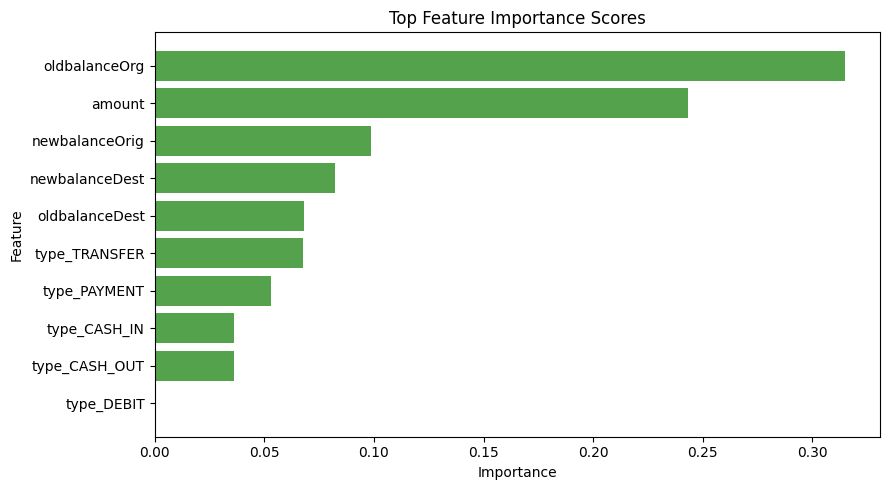

In [12]:
rf_model = trained_models.get("Random Forest", {}).get("model")
if hasattr(rf_model, "feature_importances_"):
    feature_importance_df = (
        pd.DataFrame(
            {
                "feature": feature_columns,
                "importance": rf_model.feature_importances_,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    importance_source = "Random Forest feature_importances_"
elif hasattr(best_model, "feature_importances_"):
    feature_importance_df = (
        pd.DataFrame(
            {
                "feature": feature_columns,
                "importance": best_model.feature_importances_,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    importance_source = f"{best_model_name} feature_importances_"
else:
    feature_importance_df = feature_selection_df[["feature", "score"]].rename(columns={"score": "importance"})
    importance_source = "SelectKBest ANOVA F-score"

feature_importance_payload = {
    "datasetName": "Fraud transaction dataset",
    "targetVariable": TARGET,
    "source": importance_source,
    "generatedAt": datetime.now(timezone.utc).isoformat(),
    "results": feature_importance_df.to_dict(orient="records"),
}
with FEATURE_IMPORTANCE_JSON_PATH.open("w", encoding="utf-8") as file:
    json.dump(feature_importance_payload, file, indent=2, default=str)
feature_importance_df.to_csv(FEATURE_IMPORTANCE_CSV_PATH, index=False)

display(feature_importance_df)
fig, ax = plt.subplots(figsize=(9, 5))
top_importance = feature_importance_df.head(10).sort_values("importance")
ax.barh(top_importance["feature"], top_importance["importance"], color="#54a24b")
ax.set_title("Top Feature Importance Scores")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## Feature Selection Evaluation

The best-performing classifier is retrained using only the `SelectKBest` subset. This comparison shows whether reducing the feature space preserves the model's predictive quality or removes useful fraud signals.


In [13]:
selected_X_train = X_train[selected_features]
selected_X_test = X_test[selected_features]
selected_config = model_configs[best_model_name]
selected_search = GridSearchCV(
    estimator=selected_config["estimator"],
    param_grid=selected_config["params"],
    scoring="f1",
    cv=3,
    n_jobs=1,
    refit=True,
)
selected_search.fit(selected_X_train, y_train)
selected_metrics = evaluate_model(selected_search.best_estimator_, selected_X_test, y_test)

feature_selection_comparison = pd.DataFrame(
    [
        {"setting": "All encoded features", **trained_models[best_model_name]["metrics"]},
        {"setting": f"Top {len(selected_features)} SelectKBest features", **selected_metrics},
    ]
)
display(feature_selection_comparison.drop(columns=["confusion_matrix"]))


,setting,accuracy,precision,recall,f1,roc_auc
0,All encoded features,0.9994,1.0,0.538462,0.700,0.995741
1,Top 5 SelectKBest features,0.9990,1.0,0.230769,0.375,0.765873


## Clustering

KMeans is applied without the `isFraud` label to test whether unsupervised transaction groups align with the real fraud class. Metrics include inertia, silhouette score, and Adjusted Rand Index against the held-out label used only for post-hoc interpretation.


In [14]:
cluster_sample_size = min(CLUSTER_SAMPLE_SIZE, len(X))
cluster_indices, _ = train_test_split(
    X.index,
    train_size=cluster_sample_size,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_cluster = X.loc[cluster_indices].copy()
y_cluster = y.loc[cluster_indices].copy()

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

clustering_rows = []
kmeans_models = {}
for n_clusters in [2, 3, 4, 5, 6, 8, 10]:
    for init_method in ["k-means++", "random"]:
        kmeans = KMeans(
            n_clusters=n_clusters,
            init=init_method,
            n_init=10,
            random_state=RANDOM_STATE,
        )
        cluster_labels = kmeans.fit_predict(X_cluster_scaled)
        silhouette = silhouette_score(
            X_cluster_scaled,
            cluster_labels,
            sample_size=min(2_000, len(X_cluster_scaled)),
            random_state=RANDOM_STATE,
        )
        ari = adjusted_rand_score(y_cluster, cluster_labels)
        fraud_rates = pd.DataFrame({"cluster": cluster_labels, "isFraud": y_cluster.values}).groupby("cluster")["isFraud"].mean()
        row = {
            "nClusters": n_clusters,
            "init": init_method,
            "nInit": 10,
            "inertia": float(kmeans.inertia_),
            "silhouetteScore": float(silhouette),
            "adjustedRandIndex": float(ari),
            "maxClusterFraudRate": float(fraud_rates.max()),
        }
        clustering_rows.append(row)
        kmeans_models[(n_clusters, init_method)] = (kmeans, cluster_labels)

clustering_df = pd.DataFrame(clustering_rows).sort_values("silhouetteScore", ascending=False).reset_index(drop=True)
display(clustering_df)

best_cluster_row = clustering_df.iloc[0]
best_cluster_key = (int(best_cluster_row["nClusters"]), best_cluster_row["init"])
best_kmeans, best_cluster_labels = kmeans_models[best_cluster_key]

clustering_payload = {
    "datasetName": "Fraud transaction dataset",
    "targetVariableUsedForTraining": False,
    "targetVariableUsedForEvaluation": TARGET,
    "sampleSize": int(cluster_sample_size),
    "generatedAt": datetime.now(timezone.utc).isoformat(),
    "bestConfiguration": best_cluster_row.to_dict(),
    "results": clustering_df.to_dict(orient="records"),
}
with CLUSTERING_RESULTS_JSON_PATH.open("w", encoding="utf-8") as file:
    json.dump(clustering_payload, file, indent=2, default=str)
clustering_df.to_csv(CLUSTERING_RESULTS_CSV_PATH, index=False)
print(f"Saved clustering results to {CLUSTERING_RESULTS_JSON_PATH}")


  File "C:\Users\olsas\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,nClusters,init,nInit,inertia,silhouetteScore,adjustedRandIndex,maxClusterFraudRate
0,10,random,10,7680.343520,0.805866,0.000272,0.010309
1,10,k-means++,10,7602.277551,0.799521,0.000293,0.058824
2,8,random,10,11503.565110,0.789868,0.000334,0.004870
3,8,k-means++,10,11503.565110,0.789868,0.000334,0.004870
4,6,random,10,24646.727488,0.726992,0.000406,0.006211
5,6,k-means++,10,24646.727488,0.726992,0.000406,0.006211
6,5,random,10,34019.908119,0.716765,0.000404,0.006173
7,5,k-means++,10,32795.445464,0.703397,0.000442,0.006211
8,4,random,10,42168.626095,0.693290,0.000440,0.006173
9,4,k-means++,10,42168.626095,0.693290,0.000440,0.006173


Saved clustering results to C:\Users\olsas\Downloads\fraudguard-ai\ml\results\clustering_results.json


## PCA Visualization

PCA reduces the scaled clustering feature matrix to two dimensions for visualization. The first plot colors transactions by KMeans cluster assignment; the second plot colors the same points by the true fraud label to visually compare clusters against real fraud outcomes.


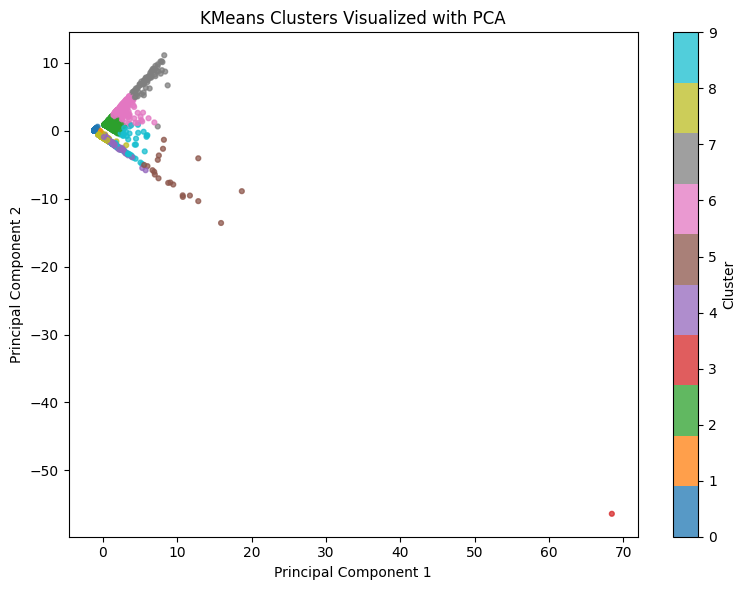

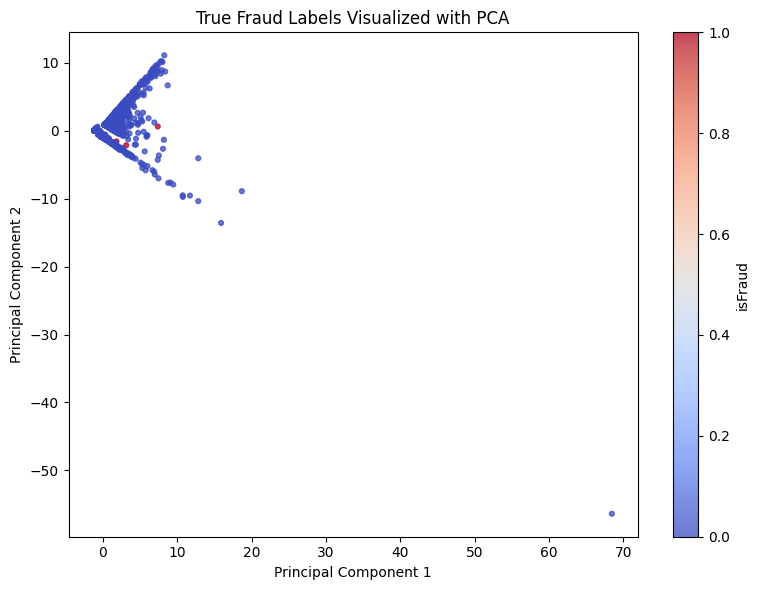

Saved PCA cluster plot: C:\Users\olsas\Downloads\fraudguard-ai\ml\results\kmeans_pca_clusters.png
Saved PCA true-label plot: C:\Users\olsas\Downloads\fraudguard-ai\ml\results\kmeans_pca_true_labels.png


In [15]:
pca_plot_size = min(PCA_PLOT_SAMPLE_SIZE, len(X_cluster_scaled))
rng = np.random.default_rng(RANDOM_STATE)
plot_positions = rng.choice(len(X_cluster_scaled), size=pca_plot_size, replace=False)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_cluster_pca = pca.fit_transform(X_cluster_scaled)
pca_plot_df = pd.DataFrame(
    {
        "PC1": X_cluster_pca[plot_positions, 0],
        "PC2": X_cluster_pca[plot_positions, 1],
        "cluster": best_cluster_labels[plot_positions],
        "isFraud": y_cluster.iloc[plot_positions].values,
    }
)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pca_plot_df["PC1"],
    pca_plot_df["PC2"],
    c=pca_plot_df["cluster"],
    cmap="tab10",
    s=12,
    alpha=0.75,
)
ax.set_title("KMeans Clusters Visualized with PCA")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
fig.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.savefig(KMEANS_PCA_CLUSTERS_PATH, dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pca_plot_df["PC1"],
    pca_plot_df["PC2"],
    c=pca_plot_df["isFraud"],
    cmap="coolwarm",
    s=12,
    alpha=0.75,
)
ax.set_title("True Fraud Labels Visualized with PCA")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
fig.colorbar(scatter, ax=ax, label="isFraud")
plt.tight_layout()
plt.savefig(KMEANS_PCA_TRUE_LABELS_PATH, dpi=150)
plt.show()

print(f"Saved PCA cluster plot: {KMEANS_PCA_CLUSTERS_PATH}")
print(f"Saved PCA true-label plot: {KMEANS_PCA_TRUE_LABELS_PATH}")


## Final Model Selection and Conclusion

The selected production candidate is the classifier with the highest held-out F1-score, because F1-score balances precision and recall for an imbalanced fraud detection problem. False positives create review workload, while false negatives allow fraudulent transactions to pass undetected, so a balanced metric is more informative than accuracy alone.

The notebook confirms that FraudGuard-AI implements preprocessing, stratified splitting, class-imbalance handling, feature selection, supervised model comparison, neural-network architecture comparison, hyperparameter tuning, confusion-matrix analysis, artifact export, KMeans clustering, and PCA visualization. Clustering is retained as exploratory analysis because it does not use fraud labels during fitting and therefore cannot replace the supervised classifier for final prediction.


In [16]:
best_metrics = trained_models[best_model_name]["metrics"]
final_summary = {
    "bestModelName": best_model_name,
    "selectionMetric": "F1-score",
    "accuracy": best_metrics["accuracy"],
    "precision": best_metrics["precision"],
    "recall": best_metrics["recall"],
    "f1Score": best_metrics["f1"],
    "rocAuc": best_metrics["roc_auc"],
    "confusionMatrix": best_metrics["confusion_matrix"],
    "selectedFeatures": selected_features,
}

best_registry_payload = {
    "bestModelName": best_model_name,
    "selectedMetric": "f1",
    "selectedHyperparameters": trained_models[best_model_name]["search"].best_params_,
    "metrics": best_metrics,
    "modelArtifact": repo_relative(BEST_MODEL_PATH),
    "compatibilityModelArtifact": repo_relative(COMPATIBILITY_MODEL_PATH),
    "columnsArtifact": repo_relative(COLUMNS_PATH),
    "generatedAt": datetime.now(timezone.utc).isoformat(),
}
with BEST_MODEL_REGISTRY_PATH.open("w", encoding="utf-8") as file:
    json.dump(best_registry_payload, file, indent=2, default=str)

metadata_payload = {
    "project": "FraudGuard-AI",
    "dataset": dataset_metadata,
    "sampleSize": int(len(sampled_df)),
    "features": FEATURES,
    "encodedFeatureColumns": feature_columns,
    "target": TARGET,
    "randomState": RANDOM_STATE,
    "testSize": TEST_SIZE,
    "sklearnVersion": sklearn_version,
    "bestModel": final_summary,
    "artifacts": {
        "bestModel": repo_relative(BEST_MODEL_PATH),
        "compatibilityModel": repo_relative(COMPATIBILITY_MODEL_PATH),
        "columns": repo_relative(COLUMNS_PATH),
        "scaler": repo_relative(SCALER_PATH),
        "bestModelRegistry": repo_relative(BEST_MODEL_REGISTRY_PATH),
    },
    "resultFiles": {
        "modelComparisonJson": repo_relative(MODEL_COMPARISON_JSON_PATH),
        "modelComparisonCsv": repo_relative(MODEL_COMPARISON_CSV_PATH),
        "featureImportanceJson": repo_relative(FEATURE_IMPORTANCE_JSON_PATH),
        "featureImportanceCsv": repo_relative(FEATURE_IMPORTANCE_CSV_PATH),
        "clusteringJson": repo_relative(CLUSTERING_RESULTS_JSON_PATH),
        "clusteringCsv": repo_relative(CLUSTERING_RESULTS_CSV_PATH),
        "kmeansPcaClusters": repo_relative(KMEANS_PCA_CLUSTERS_PATH),
        "kmeansPcaTrueLabels": repo_relative(KMEANS_PCA_TRUE_LABELS_PATH),
    },
    "generatedAt": datetime.now(timezone.utc).isoformat(),
}
with TRAINING_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(metadata_payload, file, indent=2, default=str)
with NOTEBOOK_EXPERIMENT_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(metadata_payload, file, indent=2, default=str)

display(pd.DataFrame([final_summary]).drop(columns=["confusionMatrix", "selectedFeatures"]))
print(best_reason)
print(f"Saved training metadata: {TRAINING_METADATA_PATH}")


,bestModelName,selectionMetric,accuracy,precision,recall,f1Score,rocAuc
0,Random Forest,F1-score,0.9994,1.0,0.538462,0.7,0.995741


Random Forest achieved the strongest held-out F1-score while maintaining a practical balance between precision and recall for the rare fraud class.
Saved training metadata: C:\Users\olsas\Downloads\fraudguard-ai\ml\models\training_metadata.json
